In [1]:
# =========================================================
# IMPORTS
# =========================================================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# =========================================================
# 1️⃣ DATA PATH
# =========================================================
data_dir = r"C:/Users/profr/Saksham/dataset"

# =========================================================
# 2️⃣ DATA AUGMENTATION + BINARY MODE
# =========================================================
img_height = 150
img_width = 150
batch_size = 16

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,

    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.3,
    shear_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.6, 1.4],
    fill_mode='nearest'
)

train_gen = datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',     # <<<<<< CHANGED
    subset='training'
)

val_gen = datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',     # <<<<<< CHANGED
    subset='validation',
    shuffle=False
)

print("Class Mapping:", train_gen.class_indices)

# =========================================================
# 3️⃣ CNN MODEL (Sigmoid Output)
# =========================================================
model = Sequential([

    # Block 1
    Conv2D(32, (3,3), activation='relu', padding='same',
           input_shape=(img_height, img_width, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.35),

    # Block 3
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.35),
    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.60),

    # Final binary classifier
    Dense(1, activation='sigmoid')      # <<<<<< CHANGED
])

# =========================================================
# 4️⃣ COMPILE (Binary Crossentropy)
# =========================================================
model.compile(
    optimizer=Adam(learning_rate=5e-5),   # small LR to stabilize val_loss
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

model.summary()

# =========================================================
# 5️⃣ TRAIN WITH EARLY STOPPING
# =========================================================
es = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_gen,
    epochs=25,
    validation_data=val_gen,
    callbacks=[es]
)


Found 3506 images belonging to 2 classes.
Found 876 images belonging to 2 classes.
Class Mapping: {'crowded': 0, 'not_crowded': 1}


C:\Users\profr\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 150, 150, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 150, 150, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 75, 75, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 75, 75, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 75, 75, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 75, 75, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 37, 37, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 37, 37, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 37, 37, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 37, 37, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 18, 18, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 18, 18, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 41472)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       5,308,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,402,817 (20.61 MB)

 Trainable params: 5,402,369 (20.61 MB)

 Non-trainable params: 448 (1.75 KB)

C:\Users\profr\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 333s 1s/step - accuracy: 0.6152 - loss: 1.0244 - val_accuracy: 0.3973 - val_loss: 2.7877
Epoch 2/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 268s 1s/step - accuracy: 0.6994 - loss: 0.6270 - val_accuracy: 0.6587 - val_loss: 1.0078
Epoch 3/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 262s 1s/step - accuracy: 0.6779 - loss: 0.6224 - val_accuracy: 0.7557 - val_loss: 0.7674
Epoch 4/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 276s 1s/step - accuracy: 0.7189 - loss: 0.5824 - val_accuracy: 0.7397 - val_loss: 0.7198
Epoch 5/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 340s 2s/step - accuracy: 0.7283 - loss: 0.5814 - val_accuracy: 0.7329 - val_loss: 0.8205
Epoch 6/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 333s 2s/step - accuracy: 0.7564 - loss: 0.5503 - val_accuracy: 0.7397 - val_loss: 0.7661
Epoch 7/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 290s 1s/step - accuracy: 0.7602 - loss: 0.5398 - val_accuracy: 0.7694 - val_loss: 0.7550


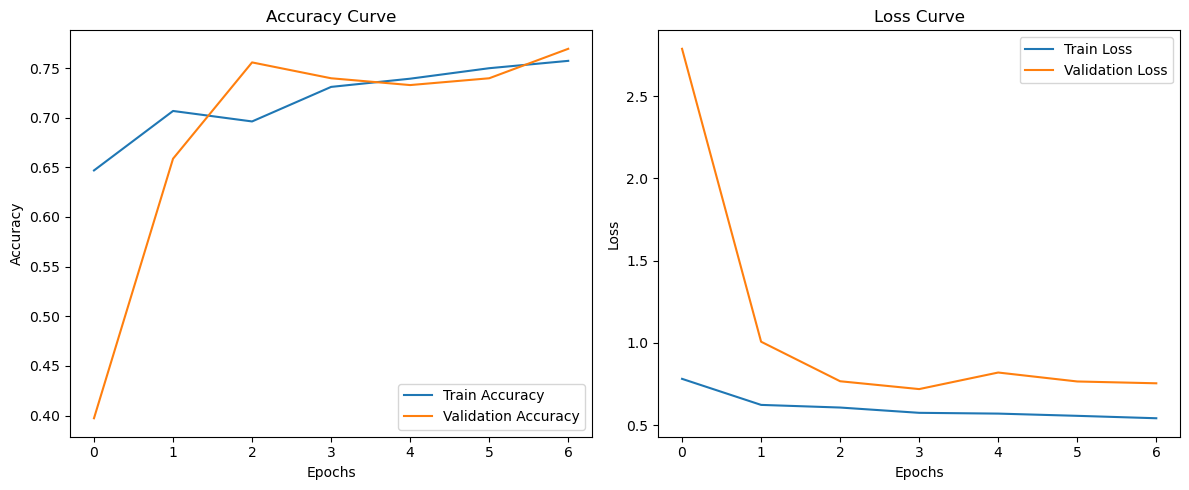

In [4]:
import matplotlib.pyplot as plt

# ---------------------------------------------------
# PLOT ACCURACY AND LOSS + SAVE AS JPEG (600 DPI)
# ---------------------------------------------------

plt.figure(figsize=(12,5))

# Accuracy graph
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train Accuracy", "Validation Accuracy"])

# Loss graph
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train Loss", "Validation Loss"])

plt.tight_layout()

# Save plot as JPEG with 600 DPI
plt.savefig("CNN.jpg", dpi=600, format='jpg')

plt.show()


55/55 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step
========== CLASSIFICATION SUMMARY REPORT ==========
              precision    recall  f1-score   support

     Class 0       0.75      0.85      0.80       528
     Class 1       0.72      0.58      0.64       348

    accuracy                           0.74       876
   macro avg       0.73      0.71      0.72       876
weighted avg       0.74      0.74      0.73       876


========== CONFUSION MATRIX ==========
[[448  80]
 [147 201]]


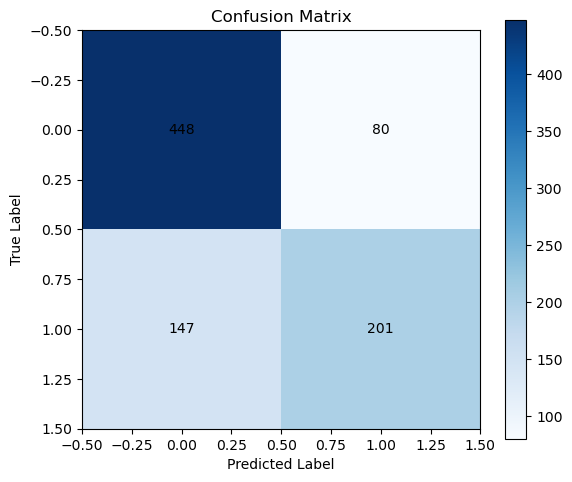

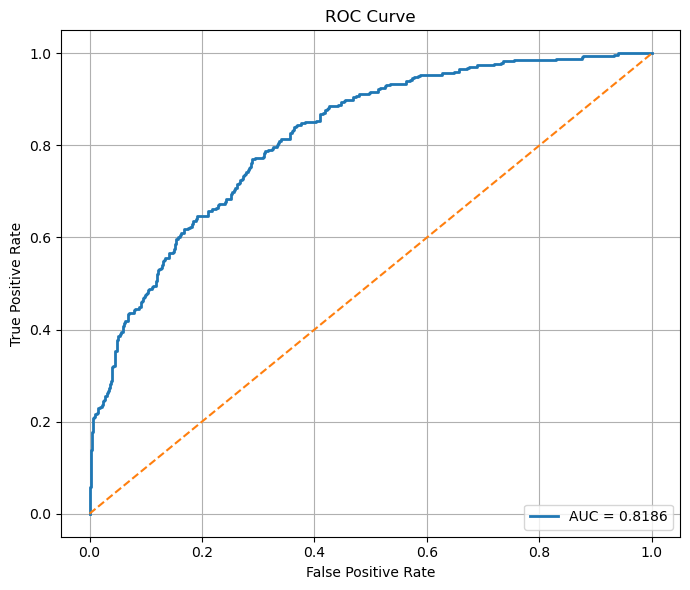

In [3]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------
# 1️⃣ PREDICT ON VALIDATION SET
# ---------------------------------------------------
y_pred_prob = model.predict(val_gen)             # probabilities (0–1)
y_pred = (y_pred_prob > 0.5).astype(int)         # binary class labels

y_true = val_gen.classes                         # original labels

# ---------------------------------------------------
# 2️⃣ CLASSIFICATION REPORT
# ---------------------------------------------------
print("========== CLASSIFICATION SUMMARY REPORT ==========")
print(classification_report(y_true, y_pred, target_names=["Class 0", "Class 1"]))

# ---------------------------------------------------
# 3️⃣ CONFUSION MATRIX
# ---------------------------------------------------
cm = confusion_matrix(y_true, y_pred)
print("\n========== CONFUSION MATRIX ==========")
print(cm)

# Confusion Matrix Heatmap
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')
plt.colorbar()
plt.tight_layout()
plt.show()

# ---------------------------------------------------
# 4️⃣ AUC – ROC CURVE
# ---------------------------------------------------
fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')  # diagonal line
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig("AUC.jpg", dpi=600, format='jpg')
plt.show()
